### Import packages & define functions

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.interpolate import PchipInterpolator

from dataclasses import dataclass, replace

# set plot showing style
%config InlineBackend.figure_format = 'retina'

# load self-defined modules
# %load_ext autoreload
# %autoreload 2
from src.model import ModelParameters, ConsolidationParameters, HebbianSequenceModel
from src.experiment import build_exp_graph, make_trials, random_walk
from src.plotNet import make_kk_layout, plot_original_network, plot_learned_network
from src.plotBehav import plot_day1_byType, plot_day2_byType

In [6]:
def Exp_simulation_day1(n_subj,
                        exposure_length,
                        params=None,
                        seed=1):
    
    if params is None:
        params = ModelParameters()

    adjacency, community, node_degree = build_exp_graph()

    subject_seeds = np.random.SeedSequence(seed).spawn(n_subj)

    all_data = []
    models = []
    trials_s2_all = []
    for iSubj, subj_seed in enumerate(subject_seeds):
        # set seeds for each subject
        exposure_seed, trial_seed = subj_seed.spawn(2)
        exposure_rng = np.random.default_rng(exposure_seed)
        trial_rng = np.random.default_rng(trial_seed)

        exposure_seq = random_walk(adjacency, 
                                   exposure_length, 
                                   exposure_rng)
        
        # train day1 model
        subj_param = replace(params)
        
        mdl_day1 = HebbianSequenceModel(
            n_nodes=adjacency.shape[0],
            params=params
        )
        mdl_day1.learn_exposure(exposure_seq)

        # generate behaviral test trials
        trials_s1, trials_s2 = make_trials(adjacency, 
                                           community, 
                                           trial_rng)
        
        ## frozen model
        # subject_data = evaluate_model(mdl_day1, 
        #                               trials, 
        #                               adjacency)

        # dynamic model that changes with test trials
        subject_data = mdl_day1.run_test_phase(trials=trials_s1)
        subject_data.insert(0, 'subj', iSubj)
        subject_data.insert(1, 'session', 'Day1')

        trials_s2_all.append(trials_s2)

        all_data.append(subject_data)
        models.append(mdl_day1)
    
    all_data = pd.concat(all_data,
                         ignore_index=True)
    
    return all_data, models, trials_s2_all

In [7]:
def Exp_simulation_day2(model_list,
                        trials_s2_list):
    all_data = []
    models_out = []
    for iSubj, model_in in enumerate(model_list):
        model_cur = model_in.copy() # so that model_in are not modified
        trials_s2_cur = trials_s2_list[iSubj]

        # generate behaviral test trials
        subject_data = model_cur.run_test_phase(trials=trials_s2_cur)
        subject_data.insert(0, 'subj', iSubj)
        subject_data.insert(1, 'session', 'Day2')

        all_data.append(subject_data)
        models_out.append(model_cur)
    
    all_data = pd.concat(all_data,
                         ignore_index=True)
    return all_data, models_out

In [9]:
palette_whole = sns.color_palette('Paired', 12)
my_color = [palette_whole[i] for i in [0, 2, 6, 4]]
my_color_s2 = [palette_whole[i] for i in [1, 3, 7, 5]]

### Simulation Start

<Axes: title={'center': 'Day 1 model predictions'}, xlabel='Trial type', ylabel='Familiarity'>

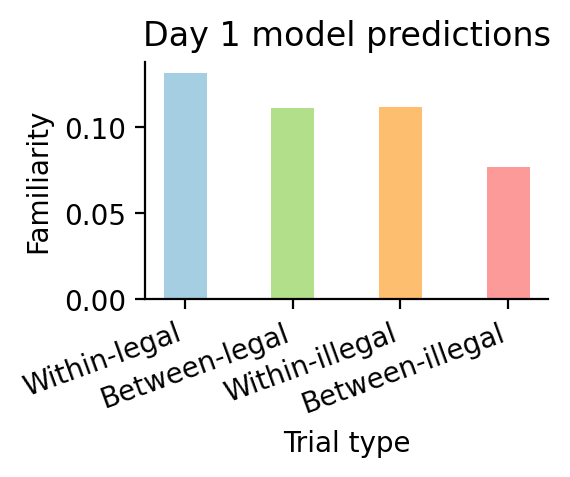

In [26]:
time_ms = 6 * 60 * 1000
iti_ms = 80
tone_ms = 100
exposure_length = time_ms // (iti_ms + tone_ms)

# specify parameters
params_tmp = ModelParameters(
    beta=0.06,
    lr=1.0,
    lr_test_prefix=0.0,
    lr_test_probe=0.0,
    reset_current_activity=True,
    decision_gain=20.0,
    criterion_offset=0.0
)

day1_data, day1_model, trials_s2_all = Exp_simulation_day1(n_subj=29, 
                                                           exposure_length=exposure_length,
                                                           params=params_tmp)

plot_day1_byType(day1_data, title="Day 1 model predictions", my_color=my_color)

c:\Users\Zhou Xiaoyue\OneDrive - University College London\Guenevere\UCL\Ph.D.project\code.model\src\plotBehav.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


(0.2, 0.8)

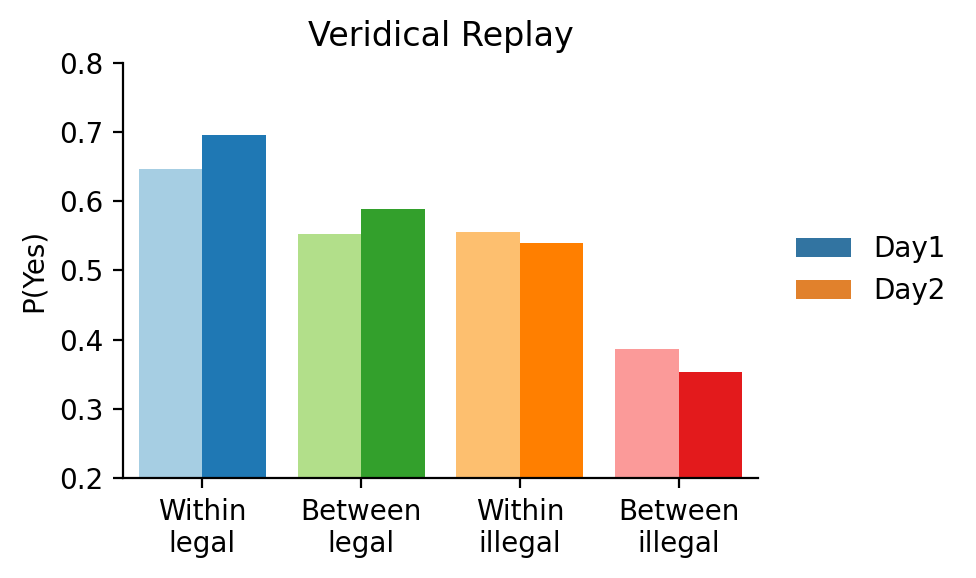

In [33]:
# Veridical replay
conso_params = ConsolidationParameters(
    conso_type = 'veridical',
    global_retention=0.8,
    n_replay=100,
    replay_length=20,
    beta_consolidation = 0.7,
    normalize_lag1_strength = True,
    lr_consolidation = 0.4
)

mdl_post_conso_list = []
for iSubj, mdl in enumerate(day1_model):
    mdl_post_conso = mdl.copy()
    rng_consolidation = np.random.default_rng(iSubj)

    mdl_post_conso.consolidation(conso_type='veridical',
                               rng = rng_consolidation,
                               conso_params = conso_params)
    
    # make sure day2 is also frozen test
    mdl_post_conso.params = replace(mdl_post_conso.params, 
                                    lr_test_prefix=0.0, 
                                    lr_test_probe=0.0)
    mdl_post_conso_list.append(mdl_post_conso)


# run day 2 experiment
model_list = mdl_post_conso_list
day2_data, model_final = Exp_simulation_day2(model_list,
                                             trials_s2_all)

fig, ax = plot_day2_byType(day1_data, 
                           day2_data, 
                           measure = 'p_yes',
                           ylab = 'P(Yes)',
                           title='Veridical Replay')
ax.set_ylim([0.2, 0.8])

c:\Users\Zhou Xiaoyue\OneDrive - University College London\Guenevere\UCL\Ph.D.project\code.model\src\plotBehav.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


(0.2, 0.8)

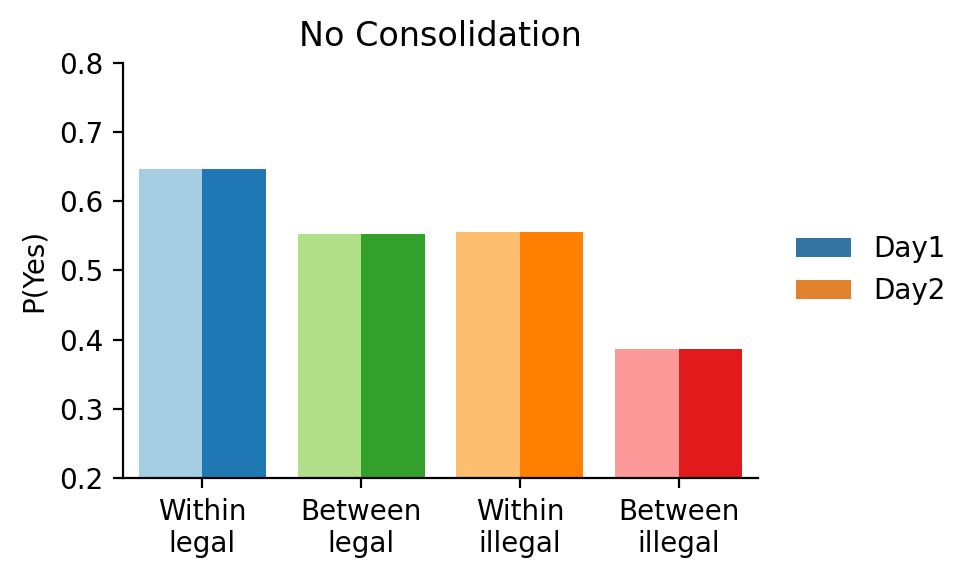

In [28]:
# No consolidation
model_list = day1_model
day2_data, model_final = Exp_simulation_day2(model_list,
                                             trials_s2_all)

fig, ax = plot_day2_byType(day1_data, 
                           day2_data, 
                           measure = 'p_yes',
                           ylab = 'P(Yes)',
                           title='No Consolidation')
ax.set_ylim([0.2, 0.8])

### Sweep parameters: beta

In [24]:
betas = np.logspace(-2.5, 1.2, 50)
n_col = 5
n_row = int(np.ceil(len(betas) / n_col))

# fig, axes = plt.subplots(
#     n_row,
#     n_col,
#     figsize=(10,5),
#     sharex = True,
#     sharey = True
# )
# axes = np.asarray(axes).ravel()

sweep_collect = []
for ibeta, beta in enumerate(betas):
    # specify parameters
    params_tmp = ModelParameters(
        beta=beta,
        lr=1.0,
        lr_test_prefix=0,
        lr_test_probe=0,
        reset_current_activity=True,
        decision_gain=20.0,
        criterion_offset=0.0
    )

    # run day 1 experiment
    day1_data, day1_model, _ = Exp_simulation_day1(n_subj=29, 
                                                exposure_length=exposure_length,
                                                params=params_tmp)
    subj_blc_data = (
        day1_data
        .groupby(['subj', 'trial_type'], 
                as_index=False)
        .agg(value = ('p_yes', 'mean'))
    )

    group_blc_data = (
        subj_blc_data
        .groupby(['trial_type'],
                as_index=False)
        .agg(mean_val = ('value', 'mean'))
    )

    group_blc_data['beta'] = beta
    sweep_collect.append(group_blc_data)

sweep_collect = pd.concat(sweep_collect, 
                          ignore_index=True)

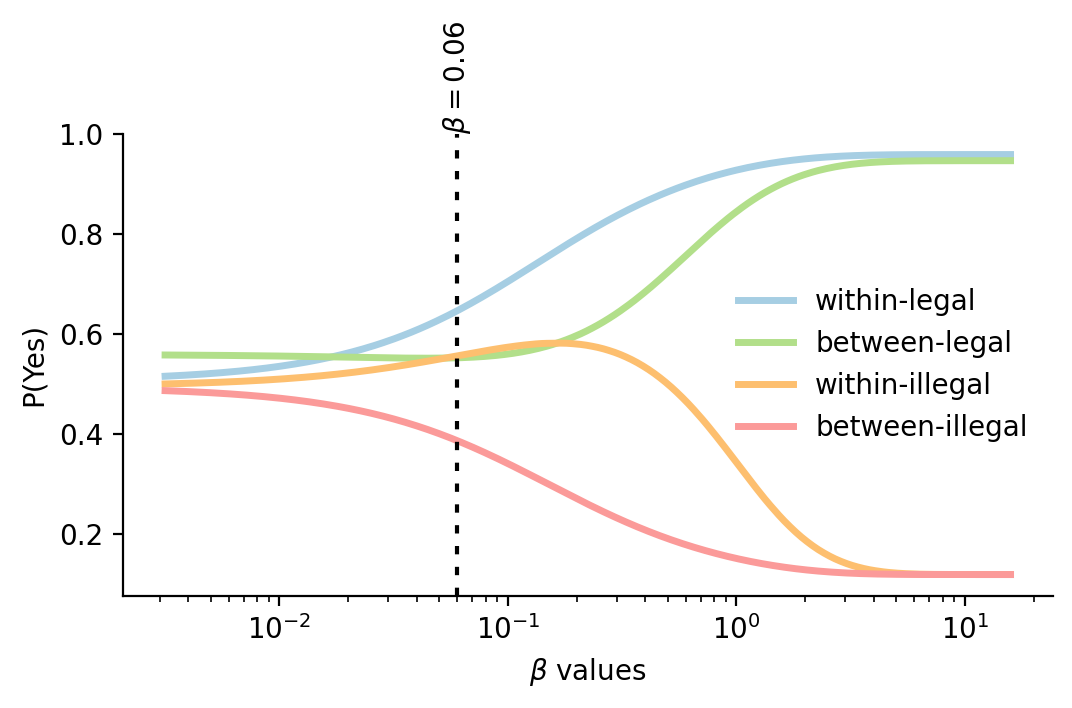

In [25]:
fig, ax = plt.subplots(figsize=(6, 3))
labels = {
    "within_legal": "within-legal",
    "between_legal": "between-legal",
    "within_illegal": "within-illegal",
    "between_illegal": "between-illegal",
}

trial_order = ['within_legal',
               'between_legal',
               'within_illegal',
               'between_illegal']

for iType, trial_type in enumerate(trial_order):
    temp = sweep_collect[sweep_collect["trial_type"] == trial_type].sort_values("beta")

    beta = temp["beta"].to_numpy()
    mean_val = temp["mean_val"].to_numpy()

    # 在 log(beta) 空间平滑
    log_beta = np.log10(beta)
    log_beta_smooth = np.linspace(log_beta.min(), log_beta.max(), 300)

    interp = PchipInterpolator(log_beta, mean_val)
    mean_smooth = interp(log_beta_smooth)

    ax.plot(
        10 ** log_beta_smooth,
        mean_smooth,
        linewidth=2.5,
        color=my_color[iType],
        label=labels[trial_type]
    )

# illustrator beta (=0.06)
best_beta = 0.06

ax.axvline(
    best_beta,
    color="black",
    linestyle=(0, (2, 3)),
    linewidth=1.5,
)

ax.text(
    best_beta,
    ax.get_ylim()[1],
    r"$\beta=0.06$",
    rotation=90,
    ha="center",
    va="bottom",
)

ax.set_xscale("log")
ax.set_xlabel(r"$\beta$ values")
ax.set_ylabel("P(Yes)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)
plt.show()

### Network Reconstruction

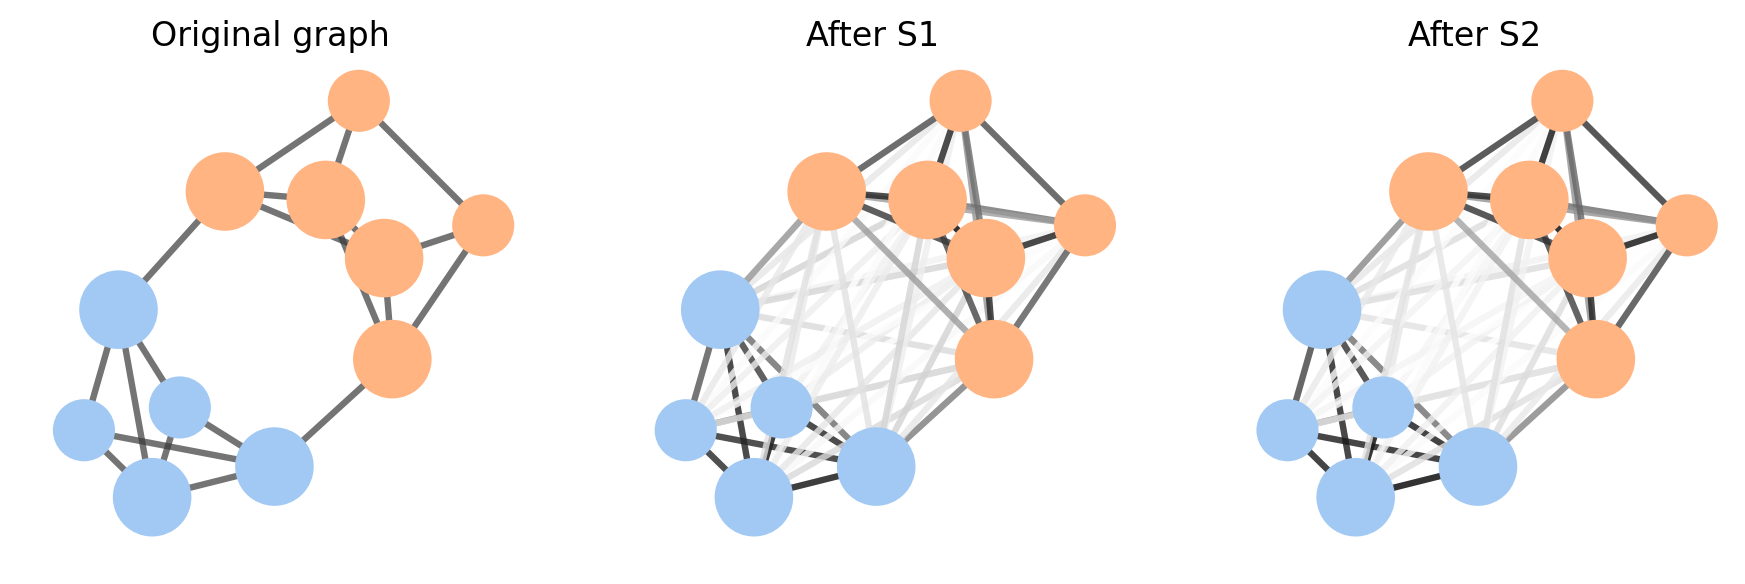

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11,4))

adjacency, community, node_deg = build_exp_graph()
pos = plot_original_network(
    adjacency=adjacency,
    community=community,
    node_deg=node_deg,
    ax=axes[0],
    title="Original graph"
)

plot_learned_network(
    W=day1_model[0].association_matrix(normalize=True),
    community=community,
    node_deg=node_deg,
    pos=pos,
    ax=axes[1],
    title="After S1",
    threshold=0.0
)

plot_learned_network(
    W=model_final[0].association_matrix(normalize=True),
    community=community,
    node_deg=node_deg,
    pos=pos,
    ax=axes[2],
    title="After S2",
    threshold=0.0
)

plt.show()

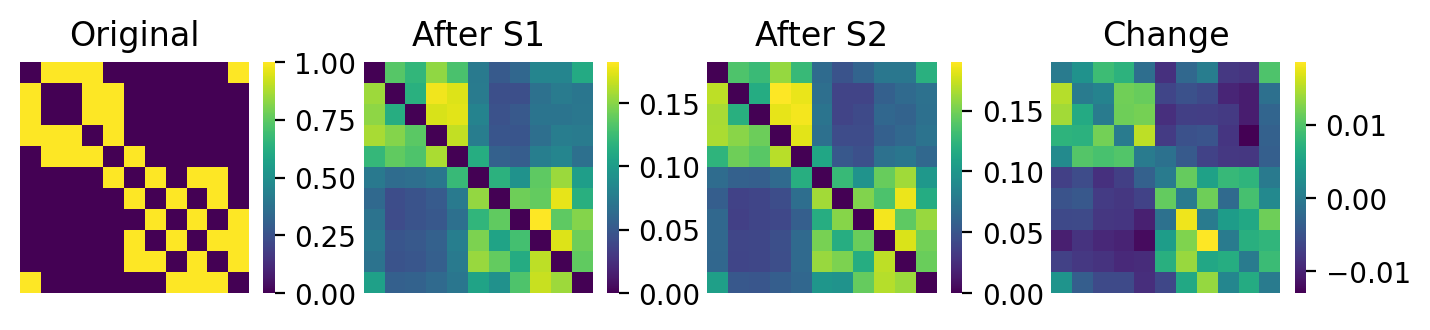

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(8.5,1.5))

sns.heatmap(adjacency, 
            cmap = 'viridis',
            xticklabels=False, 
            yticklabels=False,
            ax=axes[0])

sns.heatmap(day1_model[0].association_matrix(normalize=True), 
            cmap = 'viridis',
            xticklabels=False, 
            yticklabels=False,
            ax=axes[1])

sns.heatmap(model_final[0].association_matrix(normalize=True), 
            cmap = 'viridis',
            xticklabels=False, 
            yticklabels=False,
            ax=axes[2])

sns.heatmap(model_final[0].association_matrix(normalize=True) - day1_model[0].association_matrix(normalize=True), 
            cmap = 'viridis',
            xticklabels=False, 
            yticklabels=False,
            ax=axes[3])

axes[0].set_title('Original')
axes[1].set_title('After S1')
axes[2].set_title('After S2')
axes[3].set_title('Change')
plt.show()

In [10]:
# 用W画出几个时期represent的网络：
# after exposure
# after session 1
# after consolidation
# after session 2

# 没有consolidation下的session 2 performance?

In [11]:
# frozen-test model
# prefix-learning model
# weak probe-learning model
# full-test-learning model

# check performance change across blocks & trials

In [ ]:
# sweep throu possible beta values (how much to generalize)
betas = [0.02, 0.05, 0.08, 0.11, 0.14, 0.17]
n_col = 3
n_row = int(np.ceil(len(betas) / n_col))

fig, axes = plt.subplots(
    n_row,
    n_col,
    figsize=(10,6),
    sharex = True,
    sharey = True
)
axes = np.asarray(axes).ravel()

for ibeta, beta in enumerate(betas):
    # specify parameters
    params_tmp = ModelParameters(
        beta=beta,
        lr=1.0,
        lr_test_prefix=0.8,
        lr_test_probe=0.1,
        reset_current_activity=True,
        decision_gain=20.0,
        criterion_offset=0.0
    )

    # run day 1 experiment
    day1_data, day1_model = Exp_simulation_day1(n_subj=29, 
                                                exposure_length=exposure_length,
                                                params=params_tmp)
    
    subj_block_p, group_block_p = summarize_cross_block(
        day1_data,
        measure="expected_acc",
        trial_order=trial_order
    )

    plot_cross_block(
        group_block_p,
        ylabel="Expected Accuracy",
        title=f"beta = {beta:.2f}",
        colors=my_color,
        ax = axes[ibeta],
        show_legend=False
    )

# set legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
)

fig.suptitle("Cross-block behavior for different beta values", fontsize=14)
fig.tight_layout(rect=[0, 0, 0.88, 0.95])

plt.show()